### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")
%matplotlib inline

### Load All Files

In [2]:
telemetry = pd.read_csv('D:/Projects/predictiq/data/PdM_telemetry.csv')
errors     = pd.read_csv('D:/Projects/predictiq/data/PdM_errors.csv')
failures   = pd.read_csv('D:/Projects/predictiq/data/PdM_failures.csv')
machines   = pd.read_csv('D:/Projects/predictiq/data/PdM_machines.csv')
maint      = pd.read_csv('D:/Projects/predictiq/data/PdM_maint.csv')

# Parse datetime columns
for df in [telemetry, errors, failures, maint]:
    df['datetime'] = pd.to_datetime(df['datetime'])

### Quick Snapshot of Each File

In [3]:
datasets = {
    'telemetry': telemetry,
    'errors': errors,
    'failures': failures,
    'machines': machines,
    'maint': maint
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f" {name.upper()}")
    print(f"{'='*50}")
    print(f"Shape     : {df.shape}")
    print(f"Columns   : {list(df.columns)}")
    print(f"Nulls     : {df.isnull().sum().to_dict()}")
    print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}" 
          if 'datetime' in df.columns else "")
    display(df.head(3))


 TELEMETRY
Shape     : (876100, 6)
Columns   : ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration']
Nulls     : {'datetime': 0, 'machineID': 0, 'volt': 0, 'rotate': 0, 'pressure': 0, 'vibration': 0}
Date range: 2015-01-01 06:00:00 → 2016-01-01 06:00:00


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847



 ERRORS
Shape     : (3919, 3)
Columns   : ['datetime', 'machineID', 'errorID']
Nulls     : {'datetime': 0, 'machineID': 0, 'errorID': 0}
Date range: 2015-01-01 06:00:00 → 2016-01-01 05:00:00


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5



 FAILURES
Shape     : (761, 3)
Columns   : ['datetime', 'machineID', 'failure']
Nulls     : {'datetime': 0, 'machineID': 0, 'failure': 0}
Date range: 2015-01-02 03:00:00 → 2015-12-31 06:00:00


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2



 MACHINES
Shape     : (100, 3)
Columns   : ['machineID', 'model', 'age']
Nulls     : {'machineID': 0, 'model': 0, 'age': 0}



,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8



 MAINT
Shape     : (3286, 3)
Columns   : ['datetime', 'machineID', 'comp']
Nulls     : {'datetime': 0, 'machineID': 0, 'comp': 0}
Date range: 2014-06-01 06:00:00 → 2016-01-01 06:00:00


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3


### Telemetry Sensor Distributions

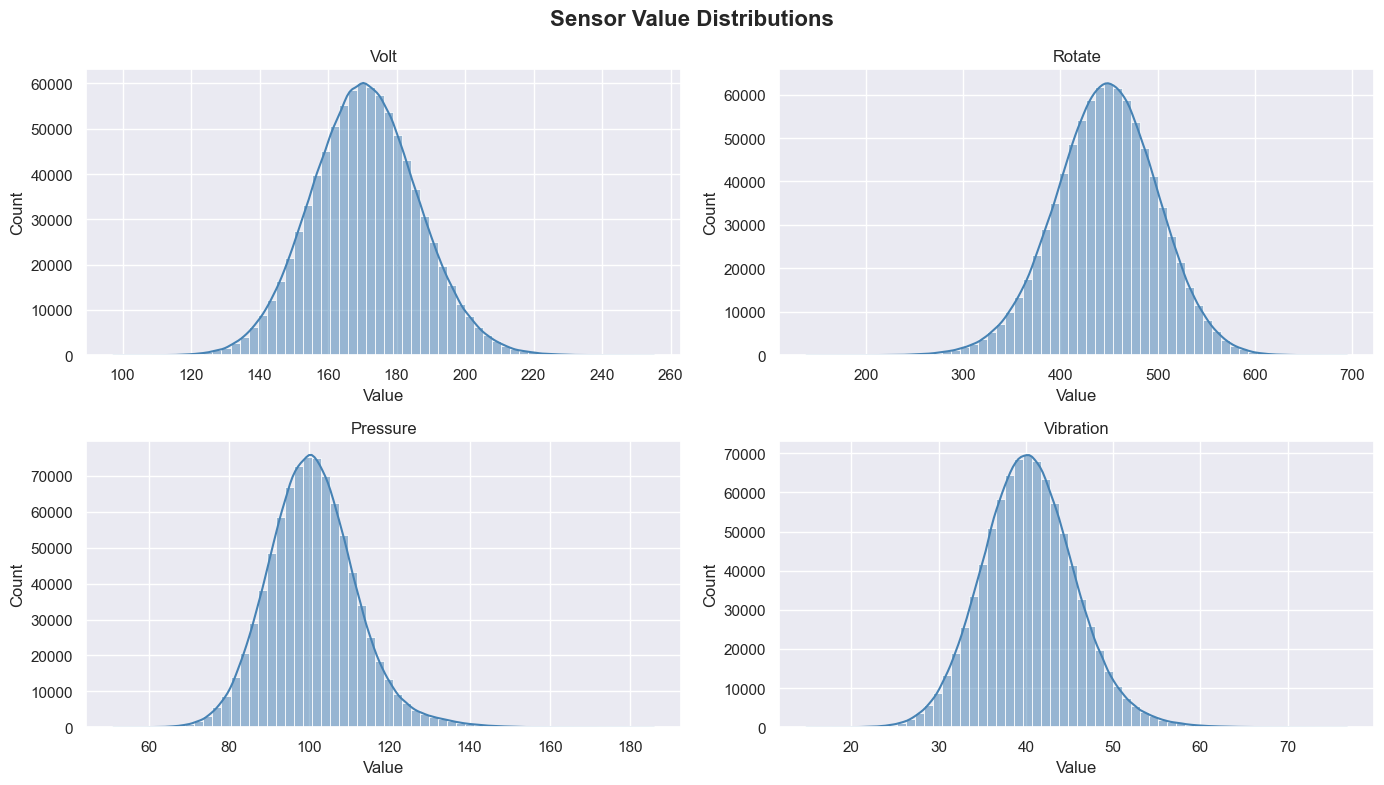

In [4]:
sensors = ['volt', 'rotate', 'pressure', 'vibration']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sensor Value Distributions', fontsize=16, fontweight='bold')

for ax, sensor in zip(axes.flatten(), sensors):
    sns.histplot(telemetry[sensor], bins=60, kde=True, ax=ax, color='steelblue')
    ax.set_title(sensor.capitalize())
    ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

### Sensor Correlation Heatmap

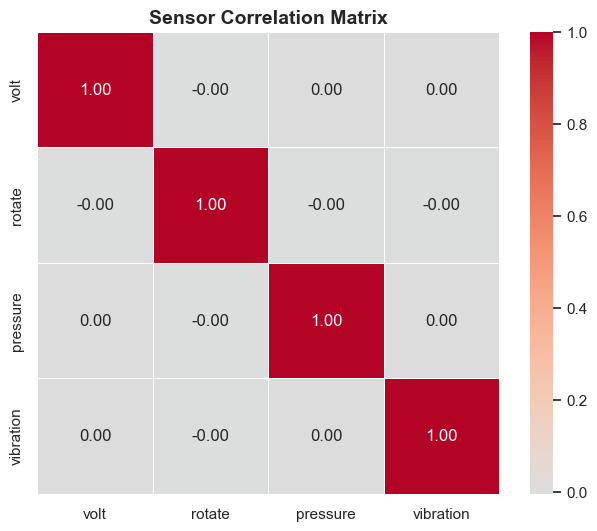

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    telemetry[sensors].corr(),
    annot=True, fmt=".2f",
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Sensor Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

### Sensor Trends Over Time (Single Machine)

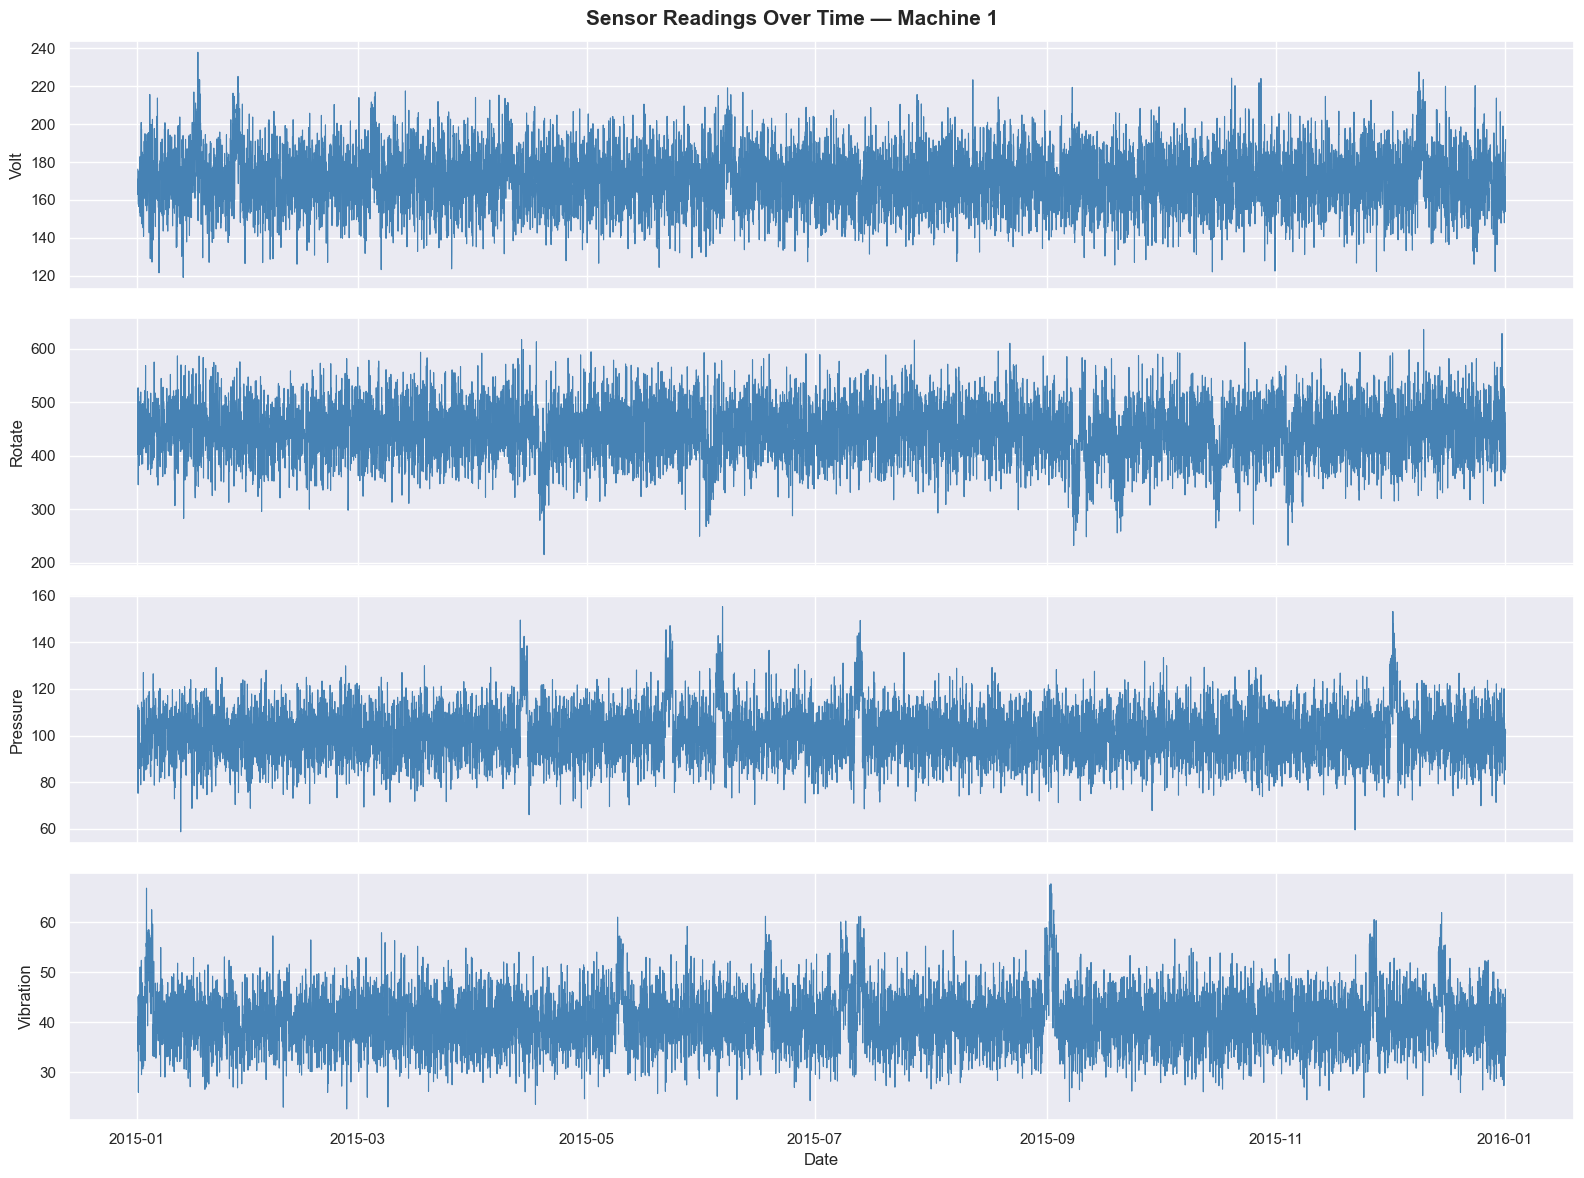

In [6]:
machine_id = 1  # pick one machine to inspect
df_machine = telemetry[telemetry['machineID'] == machine_id].sort_values('datetime')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'Sensor Readings Over Time — Machine {machine_id}', fontsize=15, fontweight='bold')

for ax, sensor in zip(axes, sensors):
    ax.plot(df_machine['datetime'], df_machine[sensor], linewidth=0.8, color='steelblue')
    ax.set_ylabel(sensor.capitalize())

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### Failure Analysis

Failure counts by component:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Unique machines with failures: 98


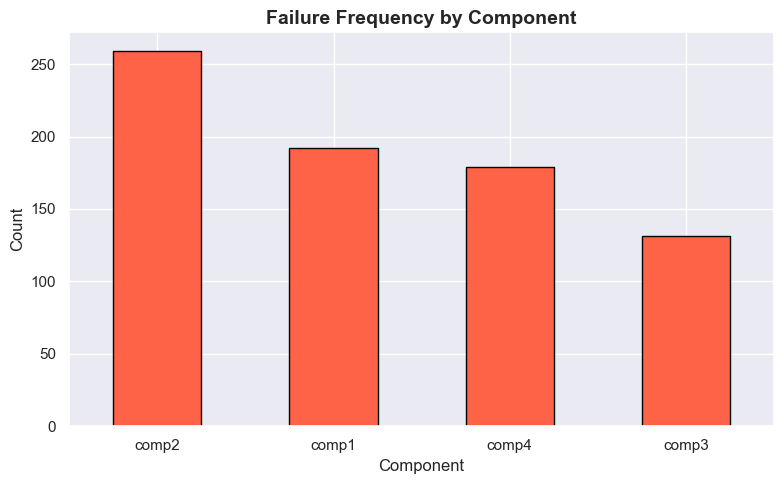

In [7]:
print("Failure counts by component:")
print(failures['failure'].value_counts())
print(f"\nUnique machines with failures: {failures['machineID'].nunique()}")

plt.figure(figsize=(8, 5))
failures['failure'].value_counts().plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Failure Frequency by Component', fontsize=14, fontweight='bold')
plt.xlabel('Component')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Failures Over Time

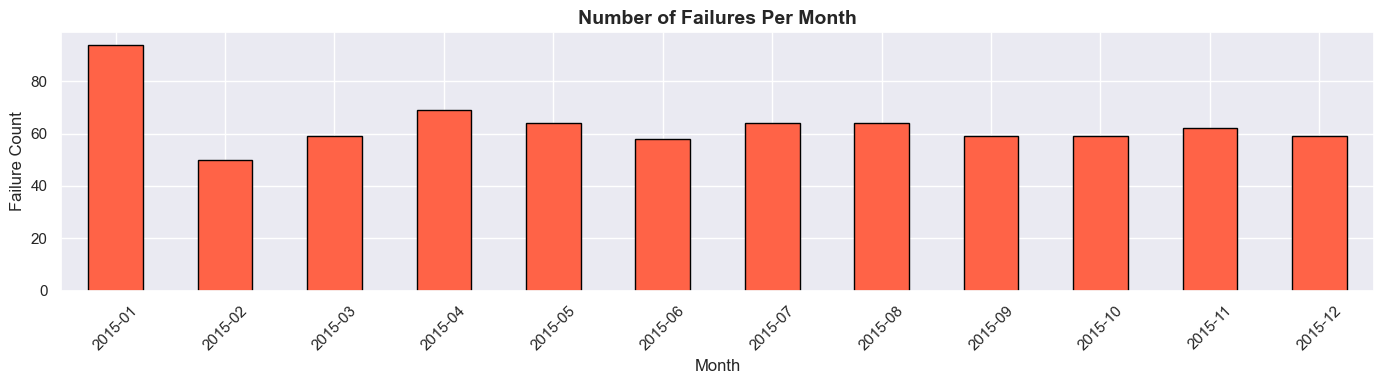

In [8]:
failures_per_month = failures.copy()
failures_per_month['month'] = failures['datetime'].dt.to_period('M')

plt.figure(figsize=(14, 4))
failures_per_month.groupby('month').size().plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Number of Failures Per Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Failure Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Error Patterns

Error counts by type:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64


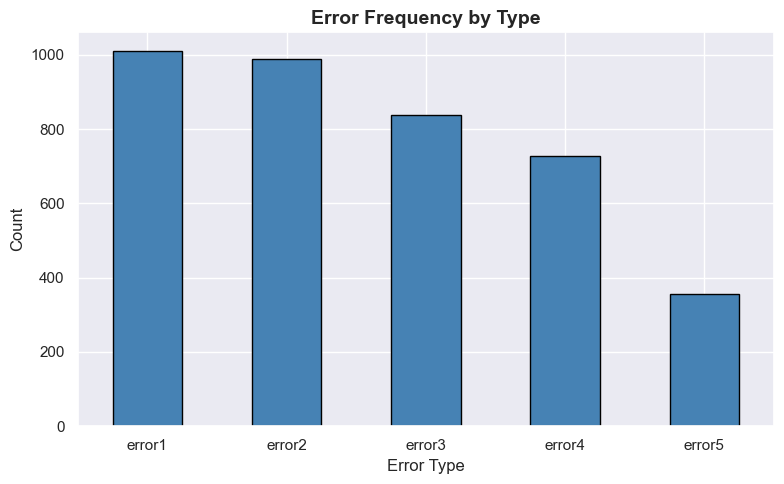

In [9]:
print("Error counts by type:")
print(errors['errorID'].value_counts())

plt.figure(figsize=(8, 5))
errors['errorID'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Error Frequency by Type', fontsize=14, fontweight='bold')
plt.xlabel('Error Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Machine Metadata

Machine model distribution:
model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64


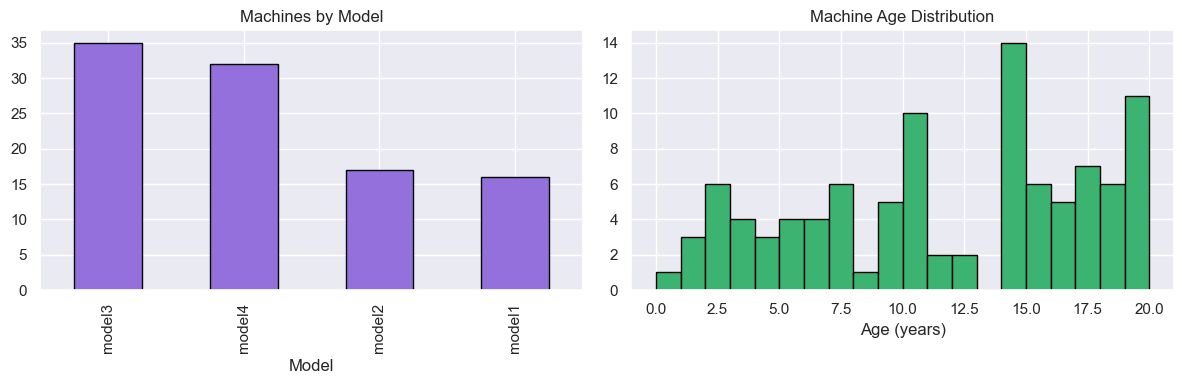

In [10]:
print("Machine model distribution:")
print(machines['model'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

machines['model'].value_counts().plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title('Machines by Model')
axes[0].set_xlabel('Model')

machines['age'].hist(bins=20, ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Machine Age Distribution')
axes[1].set_xlabel('Age (years)')

plt.tight_layout()
plt.show()